<ul>
the training set, comprising measurements of traffic congestion across 65 roadways from April through September of 1991.
<ul><li><code>row_id</code> - a unique identifier for this instance</li>
<li><code>time</code> - the 20-minute period in which each measurement was taken</li>
<li><code>x</code> - the east-west midpoint coordinate of the roadway</li>
<li><code>y</code> - the north-south midpoint coordinate of the roadway</li>
<li><code>direction</code> - the direction of travel of the roadway. <code>EB</code> indicates "eastbound" travel, for example, while <code>SW</code> indicates a "southwest" direction of travel.</li>
<li><code>congestion</code> - congestion levels for the roadway during each hour; the target. The congestion measurements have been normalized to the range 0 to 100.</li></ul></li>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [5]:
train_id = train["row_id"]
test_id = test["row_id"]
train.drop("row_id", axis=1, inplace=True)
test.drop("row_id", axis=1, inplace=True)

In [6]:
train["time"] = pd.to_datetime(train["time"])
train["hour"] = train["time"].dt.hour
train["day"] = train["time"].dt.day
train["month"] = train["time"].dt.month
train["weekday"] = train["time"].dt.weekday

test["time"] = pd.to_datetime(test["time"])
test["hour"] = test["time"].dt.hour
test["day"] = test["time"].dt.day
test["month"] = test["time"].dt.month
test["weekday"] = test["time"].dt.weekday

In [7]:
train.drop("time", axis=1, inplace=True)
test.drop("time", axis=1, inplace=True)

In [12]:
train.columns

Index(['x', 'y', 'direction', 'congestion', 'hour', 'day', 'month', 'weekday'], dtype='object')

## X and Y

In [25]:
plt.rcParams['figure.figsize'] = (10.0, 6.0)
sns.set_style("whitegrid")

<AxesSubplot:xlabel='x', ylabel='congestion'>

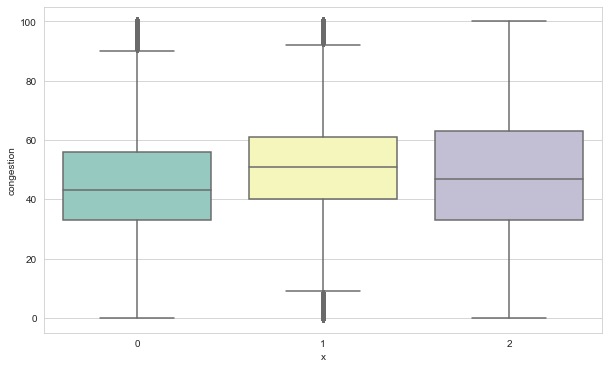

In [26]:
sns.boxplot(x="x", y="congestion", data=train)

<AxesSubplot:xlabel='y', ylabel='congestion'>

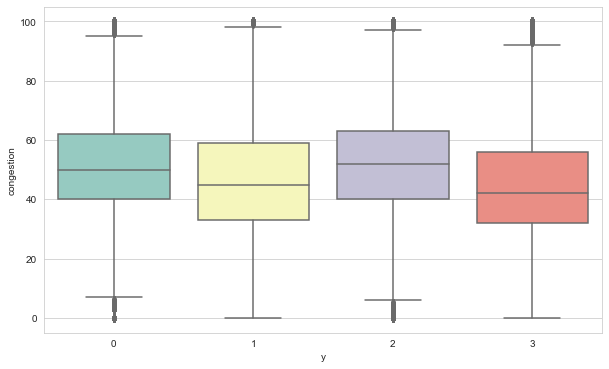

In [27]:
sns.boxplot(x="y", y="congestion", data=train)

C:\Users\harik\anaconda3\envs\data_sciences\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='congestion', ylabel='x'>

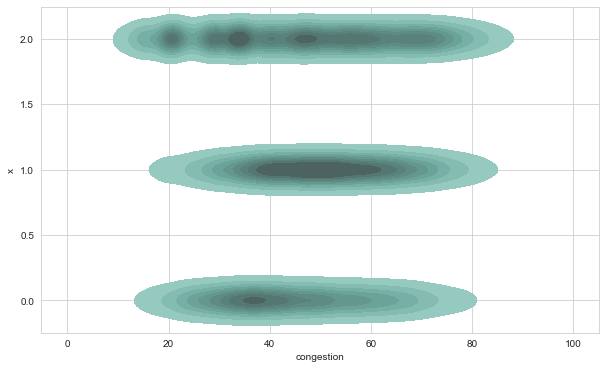

In [34]:
sns.kdeplot("congestion", "x", data=train, shade=True);